In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('C:\\Users\\manish singh\\OneDrive\\Desktop\\Desktop\\exl_database\\loan_approval_dataset_nullvalues.csv')

In [3]:
df=data.copy()

In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,NaN,No,9600000,29900000,12,778,2400000.0,17600000.0,NaN,8000000.0,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,NaN,2200000.0,8800000.0,3300000.0,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000.0,NaN,33300000.0,12800000.0,Rejected
3,4,3,NaN,No,8200000,30700000,8,467,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000.0,8200000.0,29400000.0,5000000.0,Rejected


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   4269 non-null   int64  
 1   no_of_dependents          4269 non-null   int64  
 2   education                 3629 non-null   object 
 3   self_employed             3928 non-null   object 
 4   income_annum              4269 non-null   int64  
 5   loan_amount               4269 non-null   int64  
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  3885 non-null   float64
 9   commercial_assets_value   4141 non-null   float64
 10  luxury_assets_value       4013 non-null   float64
 11  bank_asset_value          3843 non-null   float64
 12  loan_status               4269 non-null   object 
dtypes: float64(4), int64(6), object(3)
memory usage: 433.7+ KB


In [6]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,3.885000e+03,4.141000e+03,4.013000e+03,3.843000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.471197e+06,4.974934e+06,1.509556e+07,4.960161e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.513098e+06,4.377911e+06,9.128965e+06,3.229474e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.450000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
df.isnull().mean()*100

loan_id                      0.000000
no_of_dependents             0.000000
education                   14.991801
self_employed                7.987819
income_annum                 0.000000
loan_amount                  0.000000
loan_term                    0.000000
cibil_score                  0.000000
residential_assets_value     8.995081
commercial_assets_value      2.998360
luxury_assets_value          5.996721
bank_asset_value             9.978918
loan_status                  0.000000
dtype: float64

In [8]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [9]:
# droping unrelated column

df.drop('loan_id',axis=1,inplace=True)

In [10]:
df.shape

(4269, 12)

In [11]:
categorical=[]
numerical=[]

for col in df:
    if df[col].dtype=='O':
        categorical.append(col)
        
    else:
        numerical.append(col)

In [12]:
# removing leading and trailing spaces from cols

df[categorical]=df[categorical].apply(lambda x:x.str.strip())

In [13]:

print("categorical cols:",categorical)
print()
print("numerical cols:",numerical)

categorical cols: ['education', 'self_employed', 'loan_status']

numerical cols: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


# <center>====Graphical representation of columns====</center>

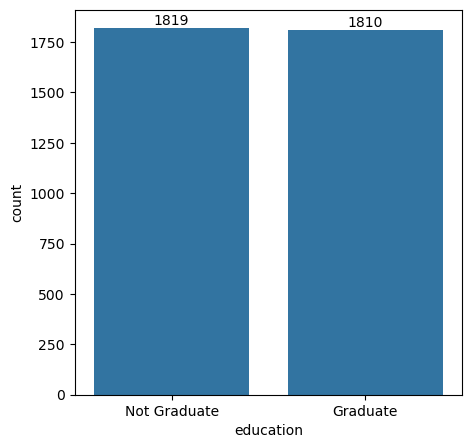

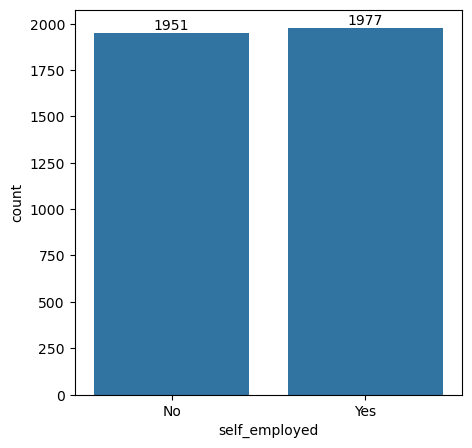

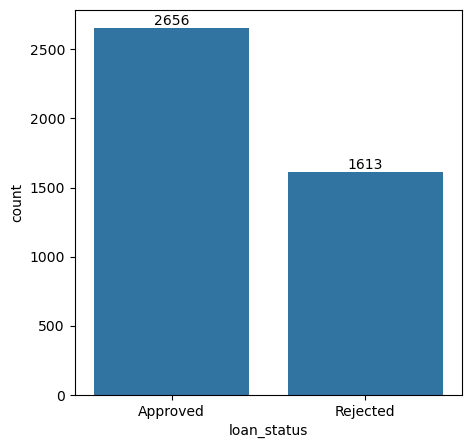

In [14]:
# countplot

for col in df[categorical]:
    plt.figure(figsize=(5,5))
    ax=sns.countplot(df[categorical],x=col)
    for bar in ax.containers:
        ax.bar_label(bar)
    

In [15]:
df['education'].unique()

array([nan, 'Not Graduate', 'Graduate'], dtype=object)

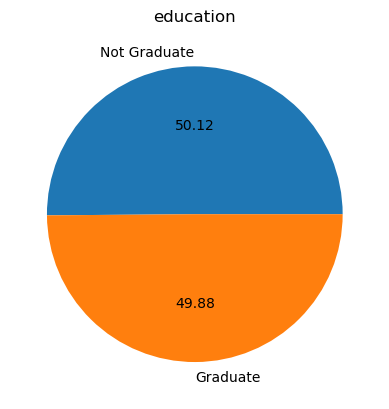

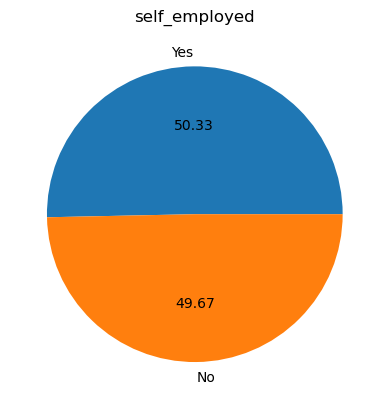

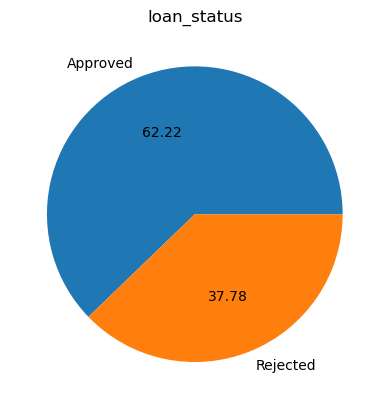

In [16]:
# pie chart of cols

for col in df[categorical]:
    df[col].value_counts()
    
    value=df[col].value_counts()
    index=df[col].value_counts().index
    
    plt.pie(x=value,labels=index,autopct='%.2f')
    plt.title(col)
    plt.show() 
    

> From the above graphs we see that in education column percentage of <b>Not Graduate(50.12%)</b> and <b>Graduate(49.88%)</b>
  is almost same . 
  
> And same for self employed column where percentage of <b>self employed(50.33%) and Not self employed(49.67%)</b> 
  is also almost equal.
  
> In Loan status column percentage of <b>Approved(62.22%) and rejected(37.78%).</b>

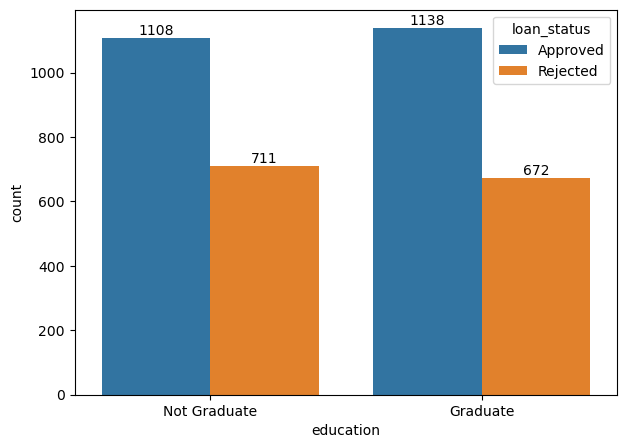

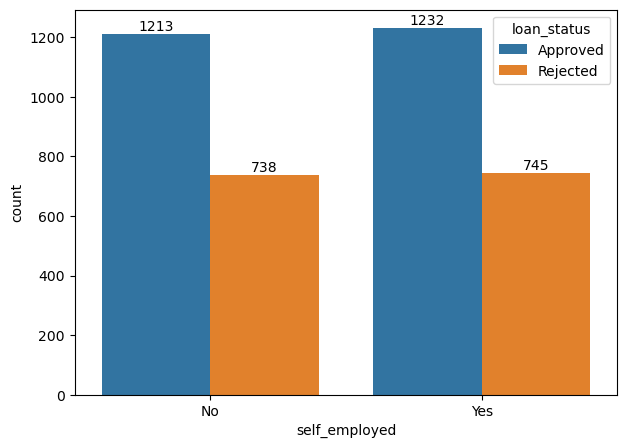

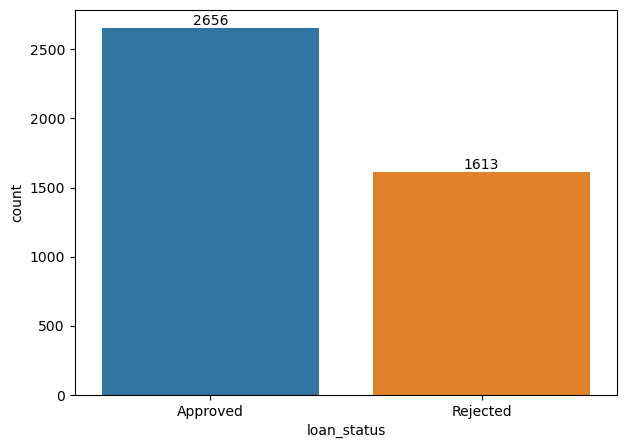

In [17]:
for col in df[categorical]:
    plt.figure(figsize=(7,5))
    ax=sns.countplot(df[categorical],x=col,hue='loan_status')
    for bar in ax.containers:
        ax.bar_label(bar)


> From the above graphs we can analysis that education does not affect the loan status as Graduate and Not Graduate 
  people have almost same level of loan approved and reject.

> And same for self employment as self employed people and Not self employed people have almost same level of loan 
  approved and reject.

# <center>====Analysing Relation between columns====</center>

In [18]:
df[numerical].corr()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
no_of_dependents,1.000000,0.007266,-0.003366,-0.020111,-0.009998,0.006737,0.000216,0.002386,0.015848
income_annum,0.007266,1.000000,0.927470,0.011488,-0.023034,0.640718,0.641498,0.930093,0.850424
loan_amount,-0.003366,0.927470,1.000000,0.008437,-0.017035,0.597658,0.605096,0.862732,0.787576
loan_term,-0.020111,0.011488,0.008437,1.000000,0.007810,0.001318,-0.005899,0.013522,0.016951
cibil_score,-0.009998,-0.023034,-0.017035,0.007810,1.000000,-0.019119,-0.003302,-0.032040,-0.010174
residential_assets_value,0.006737,0.640718,0.597658,0.001318,-0.019119,1.000000,0.423827,0.598418,0.527412
commercial_assets_value,0.000216,0.641498,0.605096,-0.005899,-0.003302,0.423827,1.000000,0.591514,0.550547
luxury_assets_value,0.002386,0.930093,0.862732,0.013522,-0.032040,0.598418,0.591514,1.000000,0.789462
bank_asset_value,0.015848,0.850424,0.787576,0.016951,-0.010174,0.527412,0.550547,0.789462,1.000000


<Axes: >

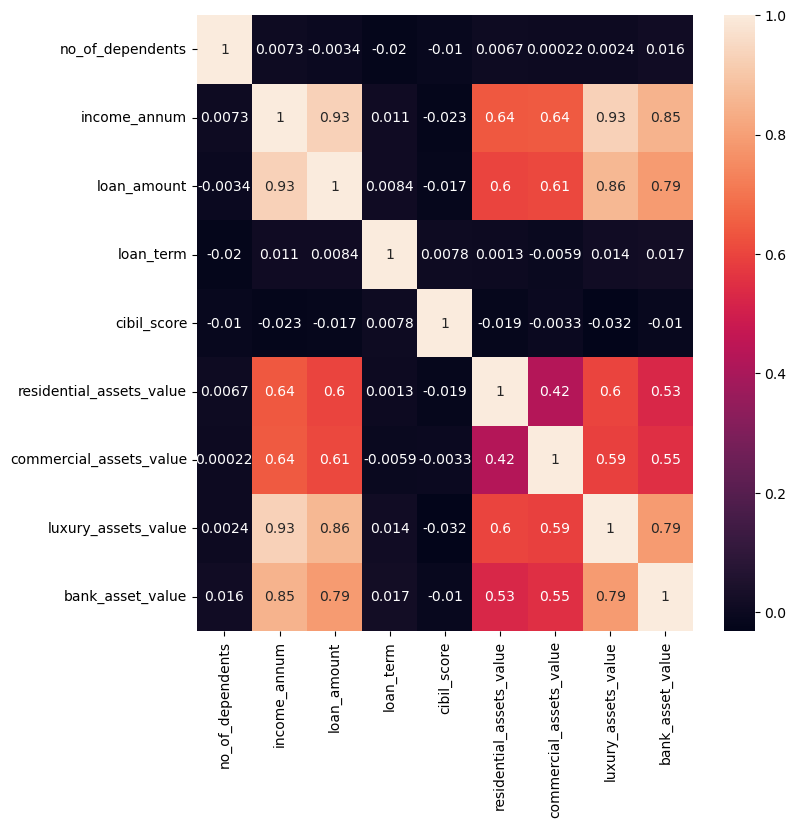

In [19]:
plt.figure(figsize=(8,8))
sns.heatmap(df[numerical].corr(),annot=True)

In [20]:
numerical

['no_of_dependents',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value']

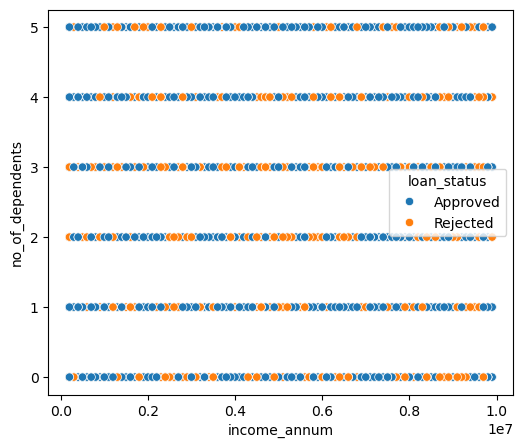

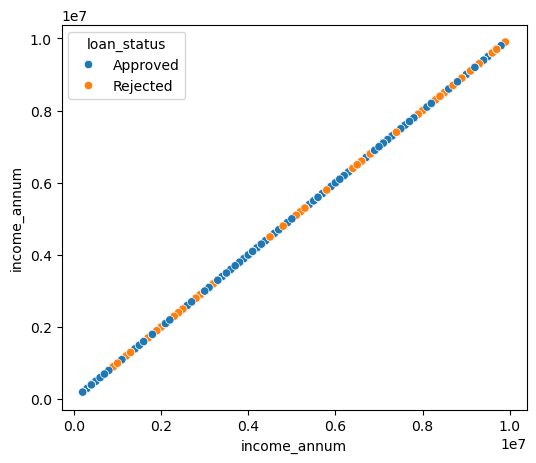

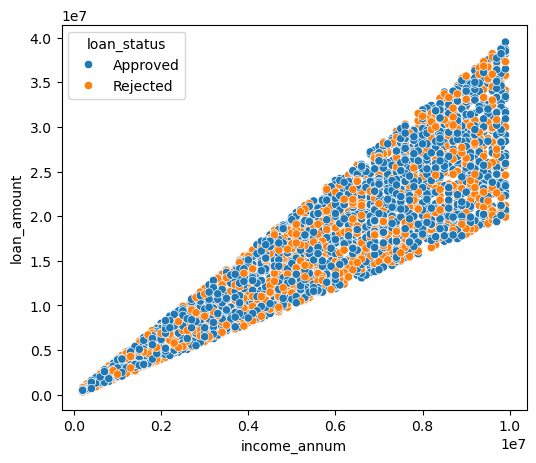

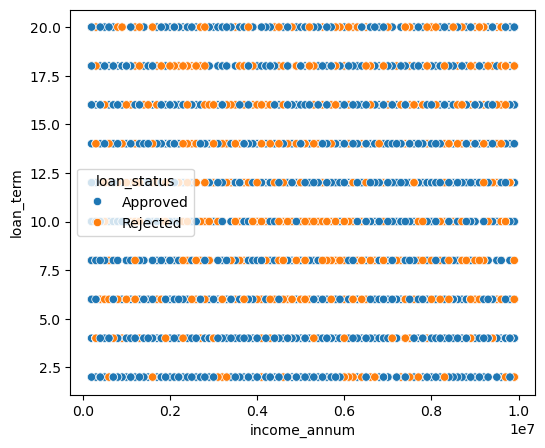

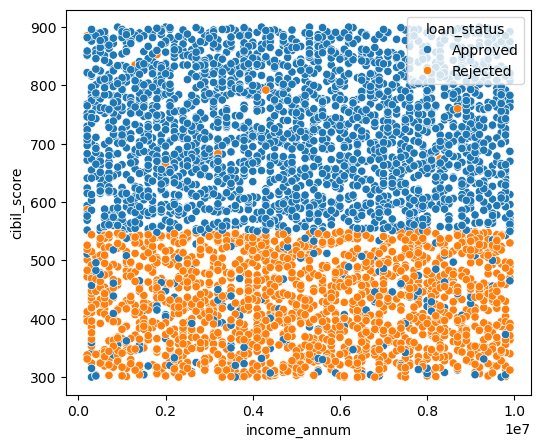

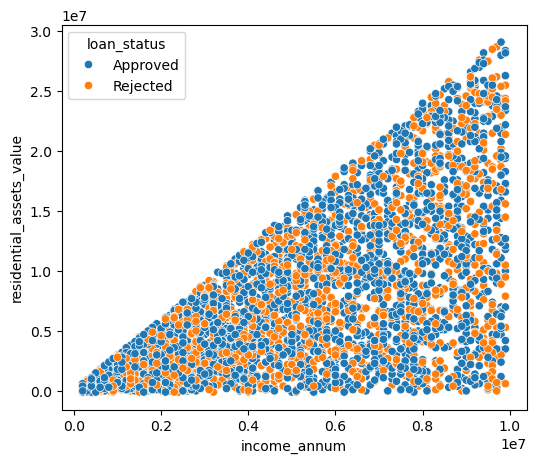

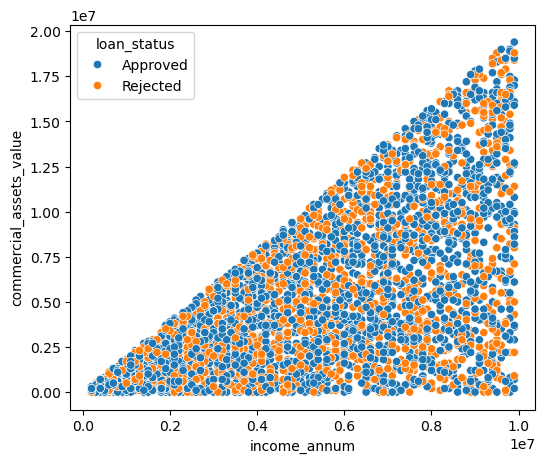

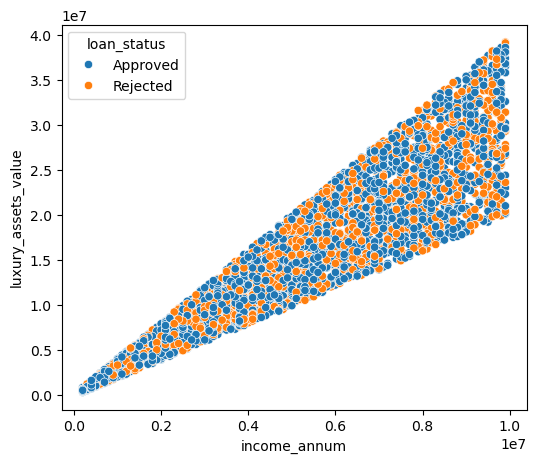

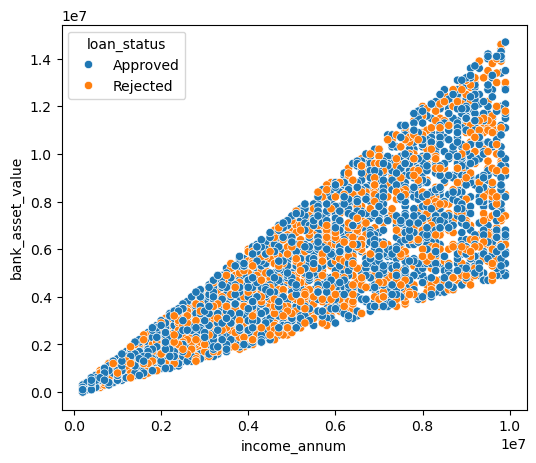

In [21]:
for num in df[numerical]:
    plt.figure(figsize=(6,5))
    sns.scatterplot(df,x='income_annum',y=num,hue='loan_status')    

> From the above graphs we can say that as income level increases than <b> bank_asset_value,luxury_assets_value ,
  commercial_assets_value,residential_assets_value and loan_amount</b> also increases/b>
  
> In <b>Cibil_score</b> it is very clear that people having score above than 550 have approved loan and below 
  than 550 are rejected. 

# <center>====Handling Missing Values====<center>

In [22]:
df.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

In [23]:
df.isnull().mean()*100

no_of_dependents             0.000000
education                   14.991801
self_employed                7.987819
income_annum                 0.000000
loan_amount                  0.000000
loan_term                    0.000000
cibil_score                  0.000000
residential_assets_value     8.995081
commercial_assets_value      2.998360
luxury_assets_value          5.996721
bank_asset_value             9.978918
loan_status                  0.000000
dtype: float64

In [24]:
print(categorical)
print()
print(numerical)

['education', 'self_employed', 'loan_status']

['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


# On categorical columns

In [25]:
df[categorical].isnull().sum()

education        640
self_employed    341
loan_status        0
dtype: int64

# <center>====Mode imputation====</center>

In [26]:
df_mode=df.copy()

<b>Mode imputation on education column</b>

In [27]:
mode_ed=df['education'].mode()[0]
print(mode_ed)

Not Graduate


In [28]:
df['education'].value_counts()

education
Not Graduate    1819
Graduate        1810
Name: count, dtype: int64

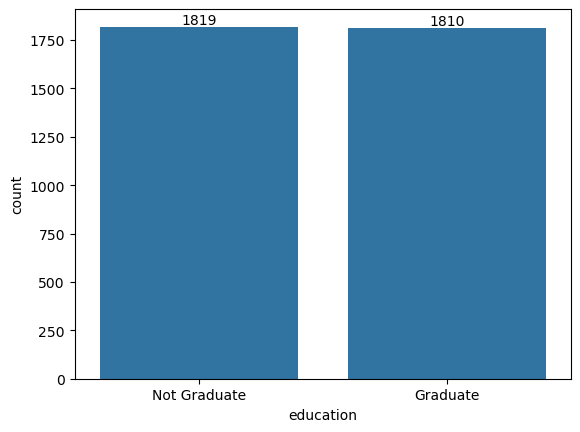

In [29]:
# countplot before imputation
ax=sns.countplot(df,x='education')
for bar in ax.containers:
    ax.bar_label(bar)

In [30]:
# imputing mode
df_mode['education'].fillna(mode_ed,inplace=True)

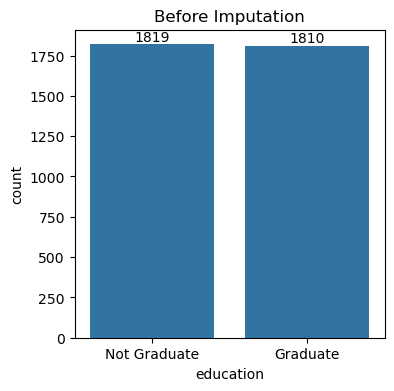

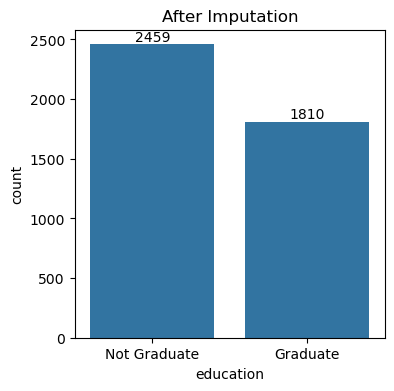

In [31]:
# comparing countplot before and after imputation

plt.figure(figsize=(4,4))
plt.title('Before Imputation')
ax=sns.countplot(df,x='education')
for bar in ax.containers:
    ax.bar_label(bar)

plt.figure(figsize=(4,4))
plt.title('After Imputation')
ax=sns.countplot(df_mode,x='education')
for bar in ax.containers:
    ax.bar_label(bar)    

<b>Mode imputation on self_employed</b>

In [32]:
mode_se=df['self_employed'].mode()[0]
print(mode_se)

Yes


In [33]:
df['self_employed'].value_counts()

self_employed
Yes    1977
No     1951
Name: count, dtype: int64

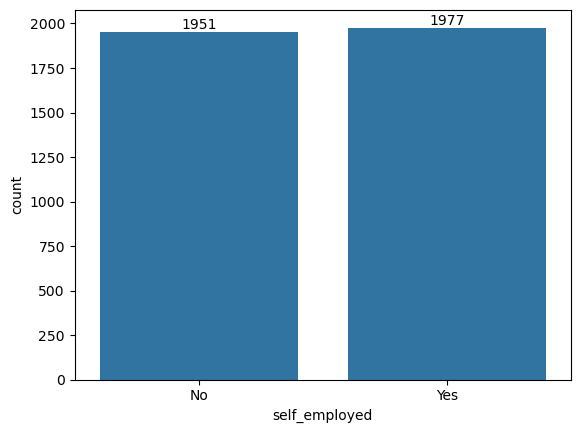

In [34]:
# countplot before imputation

ax=sns.countplot(df,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar)

In [35]:
# imputing mode
df_mode['self_employed'].fillna(mode_se,inplace=True)

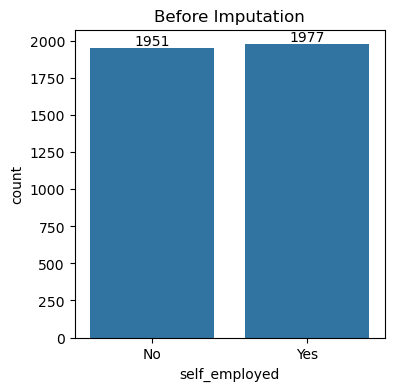

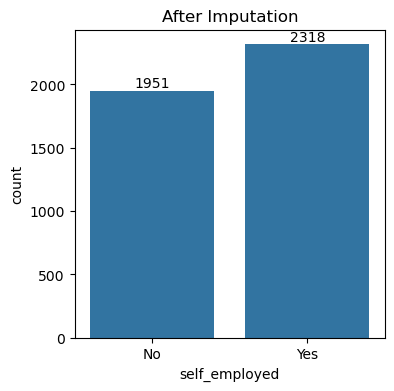

In [36]:
#comparing countplot before and after imputation

plt.figure(figsize=(4,4))
plt.title('Before Imputation')
ax=sns.countplot(df,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar)

plt.figure(figsize=(4,4))
plt.title('After Imputation')
ax=sns.countplot(df_mode,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar) 

> Mode imputation is not preferable here beacuse one category is dominating in both the columns after imputation 

# <center>====Random value  imputation====</center>

In [37]:
df_ran=df.copy()

In [38]:
df_ran.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

<b>Random value imputation on education</b>

In [39]:
df_ran.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

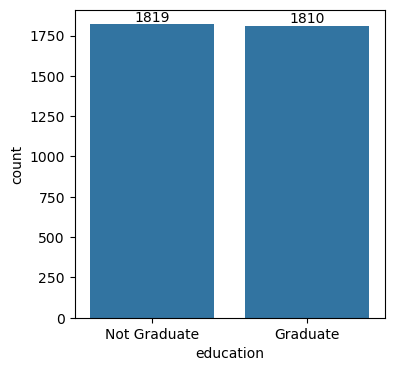

In [40]:
# countplot before imputation

plt.figure(figsize=(4,4))
ax=sns.countplot(df,x='education')
for bar in ax.containers:
    ax.bar_label(bar)

In [41]:
df['education'].value_counts()

education
Not Graduate    1819
Graduate        1810
Name: count, dtype: int64

In [42]:
not_null=df['education'].notnull().sum()
not_null

3629

In [43]:
not_gra=df[df['education']=='Not Graduate'].shape[0]
print(not_gra)

1819


In [44]:
gra=df[df['education']=='Graduate'].shape[0]
print(gra)

1810


In [45]:
# calculating probabilities

pro_not_gra=not_gra/not_null
pro_gra=gra/not_null

In [46]:
print("pro_not_gra:",pro_not_gra)
print("pro_gra:",pro_gra)

pro_not_gra: 0.5012400110223202
pro_gra: 0.4987599889776798


In [47]:
labels=df['education'].value_counts().index
print(labels)

Index(['Not Graduate', 'Graduate'], dtype='object', name='education')


In [48]:
# imputing values 

df_ran['education'].fillna(np.random.choice(labels,p=(pro_not_gra,pro_gra)),inplace=True)

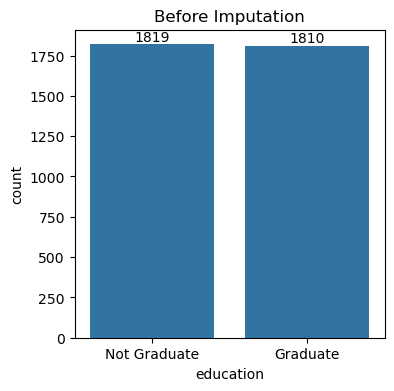

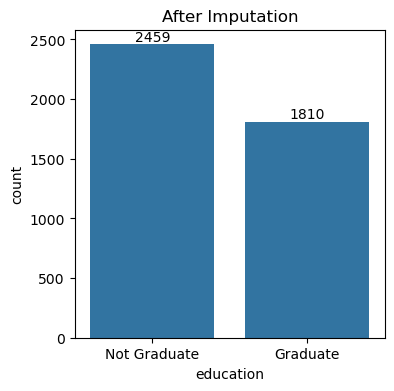

In [49]:
#comparing countplot before and after imputation


plt.figure(figsize=(4,4))
plt.title('Before Imputation')
ax=sns.countplot(df,x='education')
for bar in ax.containers:
    ax.bar_label(bar)

plt.figure(figsize=(4,4))
plt.title('After Imputation')
ax=sns.countplot(df_ran,x='education')
for bar in ax.containers:
    ax.bar_label(bar) 

<b>Random value imputation on self_employed</b> 

In [50]:
df_ran.isnull().sum()

no_of_dependents              0
education                     0
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

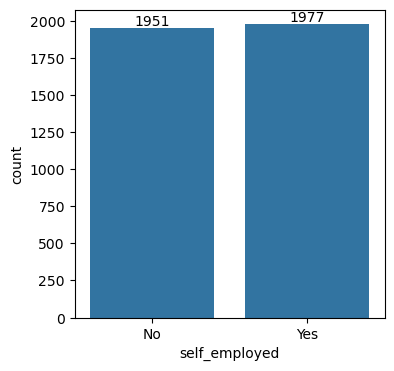

In [51]:
# countplot before imputation
plt.figure(figsize=(4,4))
ax=sns.countplot(df,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar)

In [52]:
df_ran['self_employed'].value_counts()

self_employed
Yes    1977
No     1951
Name: count, dtype: int64

In [53]:
labels1=df['self_employed'].value_counts().index
print(labels1)

Index(['Yes', 'No'], dtype='object', name='self_employed')


In [54]:
non_null1=df['self_employed'].notnull().sum()
print(non_null1)

3928


In [55]:
yes_count=df[df['self_employed']=='Yes'].shape[0]
yes_count

1977

In [56]:
no_count=df[df['self_employed']=='No'].shape[0]
no_count

1951

In [57]:
# calculating probabilities

pro_yes=yes_count/non_null1
pro_no=no_count/non_null1

In [58]:
print('pro_yes:',pro_yes)
print()
print('pro_no:',pro_no)

pro_yes: 0.5033095723014257

pro_no: 0.49669042769857435


In [59]:
#Imputing values
df_ran['self_employed'].fillna(np.random.choice(labels1,p=(pro_yes,pro_no)),inplace=True)

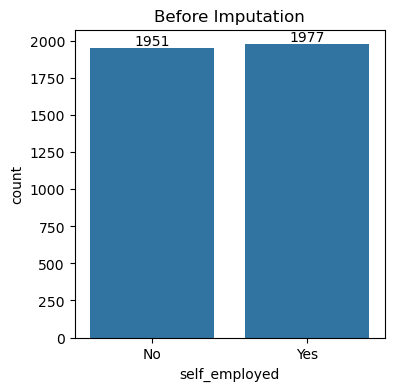

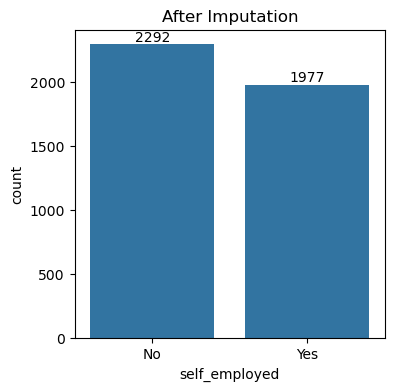

In [60]:
#comparing countplot before and after imputation


plt.figure(figsize=(4,4))
plt.title('Before Imputation')
ax=sns.countplot(df,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar)

plt.figure(figsize=(4,4))
plt.title('After Imputation')
ax=sns.countplot(df_ran,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar) 

> Random value imputation is not preferable in <b>education</b> column beacuse one category is dominating after imputation.

> where as in <b>self employed column</b> random value impuatation is preferable as there is less difference between value 
  count of both category after the imputation.

# <center>====Missing category====</center>

In [61]:
df_mis=df.copy()

In [62]:
df_mis.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

<b>Missing value indicator on education</b> 

In [63]:
df_mis['education'].fillna('Missing',inplace=True)

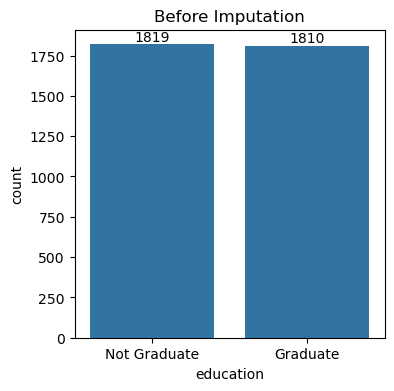

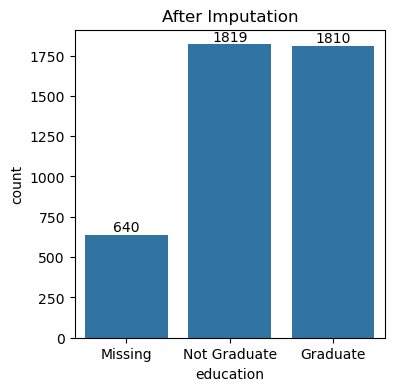

In [64]:
#comparing countplot before and after imputation


plt.figure(figsize=(4,4))
plt.title('Before Imputation')
ax=sns.countplot(df,x='education')
for bar in ax.containers:
    ax.bar_label(bar)

plt.figure(figsize=(4,4))
plt.title('After Imputation')
ax=sns.countplot(df_mis,x='education')
for bar in ax.containers:
    ax.bar_label(bar) 

<b>Missing value indicator on self employed</b>

In [65]:
df_mis['self_employed'].fillna('Missing',inplace=True)

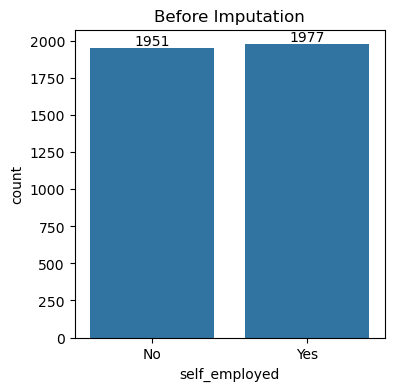

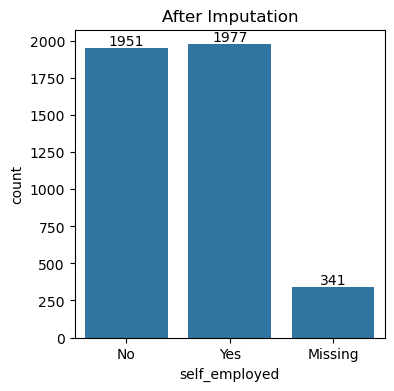

In [66]:
#comparing countplot before and after imputation


plt.figure(figsize=(4,4))
plt.title('Before Imputation')
ax=sns.countplot(df,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar)

plt.figure(figsize=(4,4))
plt.title('After Imputation')
ax=sns.countplot(df_mis,x='self_employed')
for bar in ax.containers:
    ax.bar_label(bar) 

# Conclusion:
> Mode imputation and Random value imputation both give almost same result after imputing values in <b>Education column</b>
  and in both cases one category is dominating. So,Missing indicator can be used in <b>Education column.</b>

> Random value imputation give better result than Mode imputation and Missing Indicator in <b>Self_employed column.</b>

# <center>==Handling Missing Values On Numerical Columns==</center>

In [67]:
df[numerical].isnull().sum()

no_of_dependents              0
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
dtype: int64

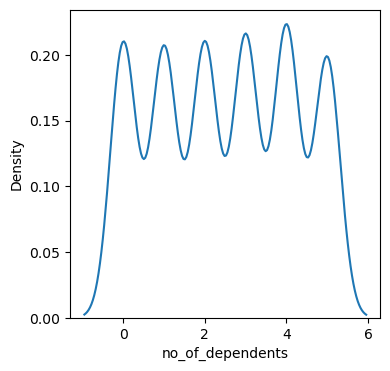

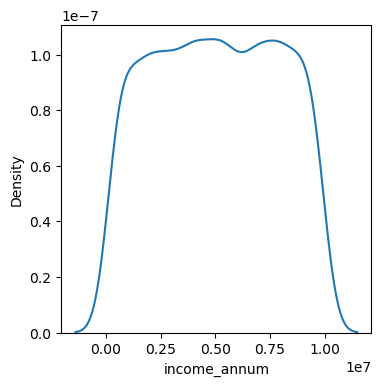

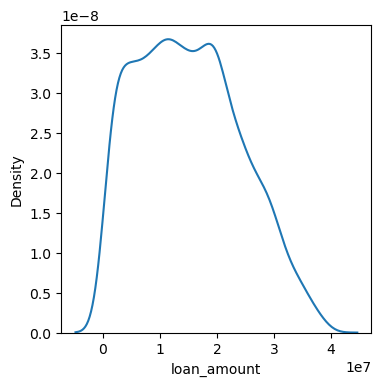

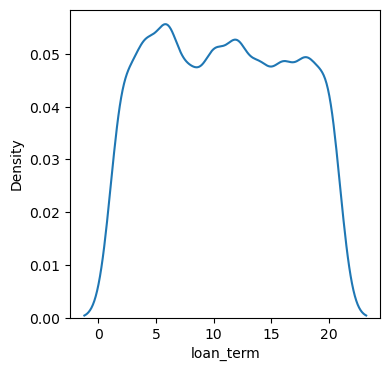

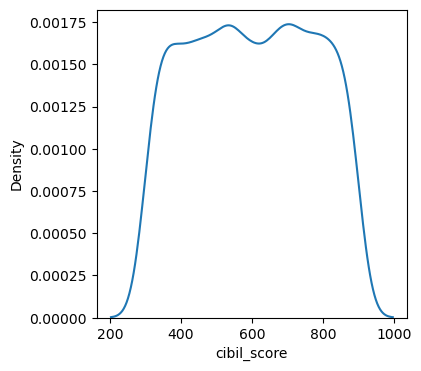

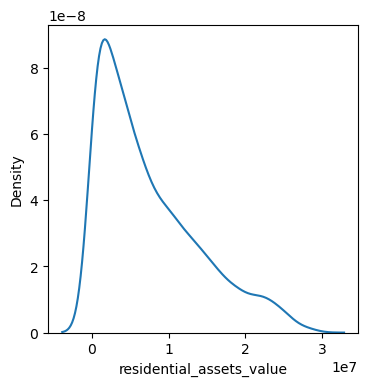

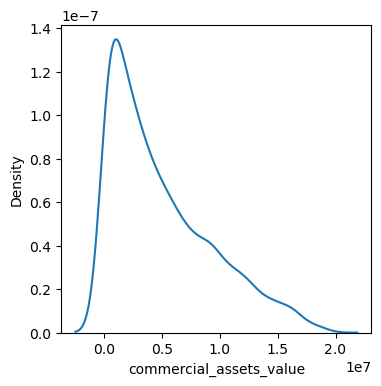

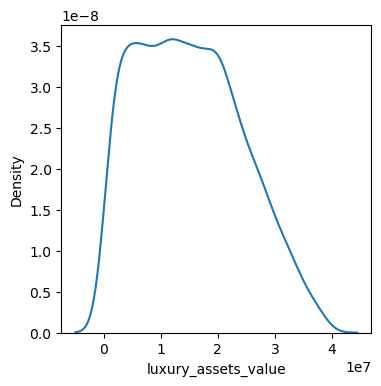

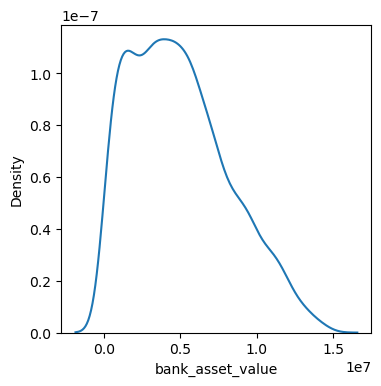

In [68]:
# checking distribution of numerical cols

for num in df[numerical]:
    plt.figure(figsize=(4,4))
    sns.kdeplot(df,x=num)

In [69]:
df_num=df.copy()
df_num.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,NaN,No,9600000,29900000,12,778,2400000.0,17600000.0,NaN,8000000.0,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,NaN,2200000.0,8800000.0,3300000.0,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000.0,NaN,33300000.0,12800000.0,Rejected
3,3,NaN,No,8200000,30700000,8,467,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000.0,8200000.0,29400000.0,5000000.0,Rejected


In [70]:
df_num.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

# <center>====Mean Imputation====</center>

<b>Mean imputation on residential_assets_value<b/>

In [71]:
rav_mean=df_num['residential_assets_value'].mean()
rav_mean

7471196.911196911

In [72]:
# imputing mean 
df_num['residential_assets_value'].fillna(rav_mean,inplace=True)

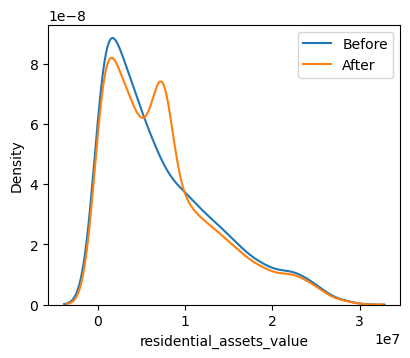

In [73]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='residential_assets_value',label='Before')
sns.kdeplot(df_num,x='residential_assets_value',label='After')
plt.legend()
plt.show()


<b>Mean imputation on commercial_assets_value</b>

In [74]:
df_num.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

In [75]:
cav_mean=df['commercial_assets_value'].mean()
cav_mean

4974933.590920067

In [76]:
# imputing mean 
df_num['commercial_assets_value'].fillna(cav_mean,inplace=True)

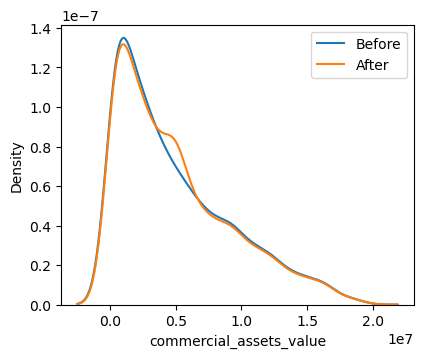

In [77]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='commercial_assets_value',label='Before')
sns.kdeplot(df_num,x='commercial_assets_value',label='After')
plt.legend()
plt.show()

<b>Mean imputation on luxury_assets_value<b/>  

In [78]:
df_num.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value       0
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

In [79]:
lav_mean=df['luxury_assets_value'].mean()
lav_mean

15095564.41564914

In [80]:
#imputing values
df_num['luxury_assets_value'].fillna(lav_mean,inplace=True)

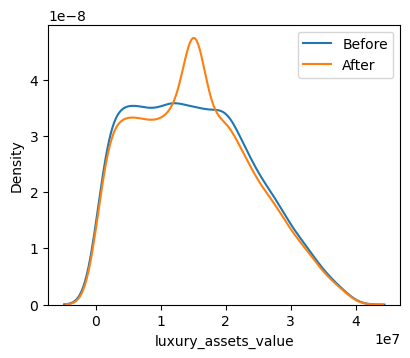

In [81]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='luxury_assets_value',label='Before')
sns.kdeplot(df_num,x='luxury_assets_value',label='After')
plt.legend()
plt.show()

<b>Mean imputation on bank_asset_value</b>

In [82]:
df_num.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value       0
luxury_assets_value           0
bank_asset_value            426
loan_status                   0
dtype: int64

In [83]:
bav_mean=df['bank_asset_value'].mean()
bav_mean

4960161.332292479

In [84]:
df_num['bank_asset_value'].fillna(bav_mean,inplace=True)

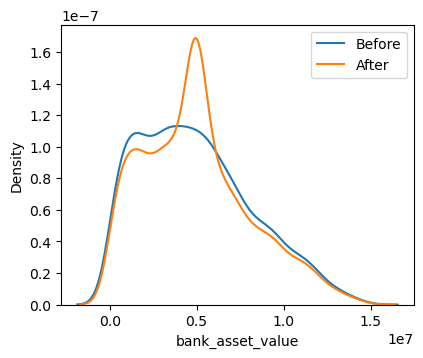

In [85]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='bank_asset_value',label='Before')
sns.kdeplot(df_num,x='bank_asset_value',label='After')
plt.legend()
plt.show()

In [86]:
df_num.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value       0
luxury_assets_value           0
bank_asset_value              0
loan_status                   0
dtype: int64

> Mean imputation is not preferable for <b>columns residential_assets_value,luxury_assets_value and bank_asset_value</b>
  because there is very big difference in curves after the imputation in all three columns.
  
> But for <b>commercial_assets_value</b>  Mean imputation can be used as there is very less difference in curve after             imputation.

# <center>====Median Imputation====<center>

In [87]:
df_mdn=df.copy()
df_mdn.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,NaN,No,9600000,29900000,12,778,2400000.0,17600000.0,NaN,8000000.0,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,NaN,2200000.0,8800000.0,3300000.0,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000.0,NaN,33300000.0,12800000.0,Rejected
3,3,NaN,No,8200000,30700000,8,467,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000.0,8200000.0,29400000.0,5000000.0,Rejected


In [88]:
df_mdn.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

<b>Median imputation on residential_assets_value</b>

In [89]:
rav_median=df['residential_assets_value'].median()
rav_median

5600000.0

In [90]:
#imputing median
df_mdn['residential_assets_value'].fillna(rav_median,inplace=True)

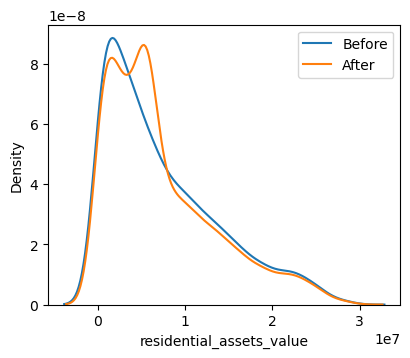

In [91]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='residential_assets_value',label='Before')
sns.kdeplot(df_mdn,x='residential_assets_value',label='After')
plt.legend()
plt.show()

In [92]:
df_mdn.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

<b>Median imputation on commercial_assets_value</b>

In [93]:
cav_median=df['commercial_assets_value'].median()
cav_median

3700000.0

In [94]:
df_mdn['commercial_assets_value'].fillna(cav_median,inplace=True)

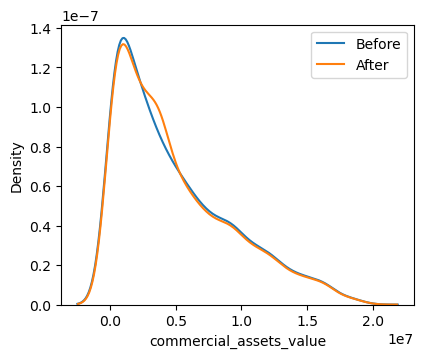

In [95]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='commercial_assets_value',label='Before')
sns.kdeplot(df_mdn,x='commercial_assets_value',label='After')
plt.legend()
plt.show()

In [96]:
df_mdn.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value       0
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

<b>Median imputation on luxury_assets_value</b>

In [97]:
lav_median=df['luxury_assets_value'].median()
lav_median

14500000.0

In [98]:
df_mdn['luxury_assets_value'].fillna(lav_median,inplace=True)

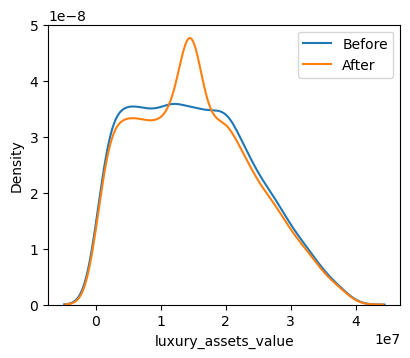

In [99]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='luxury_assets_value',label='Before')
sns.kdeplot(df_mdn,x='luxury_assets_value',label='After')
plt.legend()
plt.show()

In [100]:
df_mdn.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value       0
luxury_assets_value           0
bank_asset_value            426
loan_status                   0
dtype: int64

<b>Median imputation on bank_asset_value</b>

In [101]:
bav_median=df['bank_asset_value'].median()
bav_median

4600000.0

In [102]:
df_mdn['bank_asset_value'].fillna(bav_median,inplace=True)

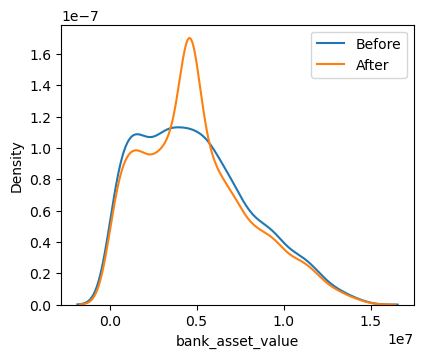

In [103]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='bank_asset_value',label='Before')
sns.kdeplot(df_mdn,x='bank_asset_value',label='After')
plt.legend()
plt.show()

In [104]:
df_mdn.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value       0
luxury_assets_value           0
bank_asset_value              0
loan_status                   0
dtype: int64

> Median imputation is not preferable for <b>columns luxury_assets_value and bank_asset_value</b> because there is 
  very big difference in curves after the imputation in all three columns.
  
> But for <b>residential_assets_value and commercial_assets_value</b>  Median imputation can be used as there is very 
  less difference in curve after imputation.

# <center>====Random value imputation ====</center>

In [105]:
df_ran1=df.copy()
df_ran1.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,NaN,No,9600000,29900000,12,778,2400000.0,17600000.0,NaN,8000000.0,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,NaN,2200000.0,8800000.0,3300000.0,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000.0,NaN,33300000.0,12800000.0,Rejected
3,3,NaN,No,8200000,30700000,8,467,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000.0,8200000.0,29400000.0,5000000.0,Rejected


In [106]:
df_ran1.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value    384
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

<b>Random value imputation on residential_assets_value</b>  

In [107]:
rav_missing=df_ran1['residential_assets_value'].isnull().sum()
rav_missing

384

In [108]:
# Creating pool 
rav_pool = df_ran1['residential_assets_value'].dropna().sample(rav_missing).values
rav_pool

array([ 5200000., 17600000.,  3000000., 14700000., 11400000., 18700000.,
        1700000.,   200000., 11200000., 12700000.,   300000.,   100000.,
       13100000.,  5100000.,  7400000., 10600000., 13000000., 15600000.,
        9800000., 24800000., 22000000.,   700000., 24700000.,  6400000.,
       10500000.,  7600000.,  5500000., 19000000., 14600000., 12100000.,
        4200000., 11700000., 17700000., 12300000., 10600000.,  3000000.,
       12000000., 22900000.,   800000.,  2900000., 24200000., 13300000.,
        9000000.,  9200000.,  3900000.,  4500000.,  4200000., 18100000.,
        6200000.,  4200000., 21500000.,  1400000., 11800000.,  4500000.,
       12900000., 17200000.,  3100000., 16500000., 12200000., 23200000.,
         500000.,  7000000., 16100000.,  2200000.,  4300000.,   600000.,
         800000.,  4100000., 25600000.,  5600000.,  3200000.,   300000.,
       16200000.,  1500000., 10900000., 12700000., 12700000., 17600000.,
        1000000.,   200000., 15600000.,  2800000., 

In [109]:
#imputing values

df_ran1['residential_assets_value'][df['residential_assets_value'].isnull()]=rav_pool

C:\Users\manish singh\AppData\Local\Temp\ipykernel_3604\2343032631.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ran1['residential_assets_value'][df['residential_assets_value'].isnull()]=rav_pool


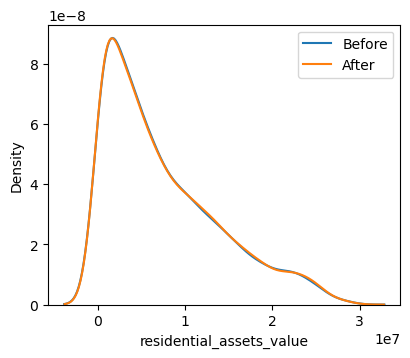

In [110]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='residential_assets_value',label='Before')
sns.kdeplot(df_ran1,x='residential_assets_value',label='After')
plt.legend()
plt.show()

<b>Random value imputation on commercial_assets_value</b>

In [111]:
df_ran1.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value     128
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

In [112]:
cav_missing=df_ran1['commercial_assets_value'].isnull().sum()
cav_missing

128

In [113]:
# Creating pool 
cav_pool=df_ran1['commercial_assets_value'].dropna().sample(cav_missing).values

In [114]:
#imputing values
df_ran1['commercial_assets_value'][df_ran1['commercial_assets_value'].isnull()]=cav_pool

C:\Users\manish singh\AppData\Local\Temp\ipykernel_3604\1375100175.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ran1['commercial_assets_value'][df_ran1['commercial_assets_value'].isnull()]=cav_pool


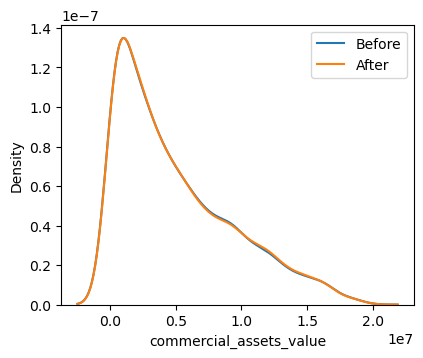

In [115]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='commercial_assets_value',label='Before')
sns.kdeplot(df_ran1,x='commercial_assets_value',label='After')
plt.legend()
plt.show()

<b>Random value imputation on luxury_assets_value</b>

In [116]:
df_ran1.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value       0
luxury_assets_value         256
bank_asset_value            426
loan_status                   0
dtype: int64

In [117]:
lav_missing=df_ran1['luxury_assets_value'].isnull().sum()
lav_missing

256

In [118]:
# creating pool
lav_pool=df['luxury_assets_value'].dropna().sample(lav_missing).values

In [119]:
#imputing values
df_ran1['luxury_assets_value'][df_ran1['luxury_assets_value'].isnull()]=lav_pool

C:\Users\manish singh\AppData\Local\Temp\ipykernel_3604\2098461893.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ran1['luxury_assets_value'][df_ran1['luxury_assets_value'].isnull()]=lav_pool


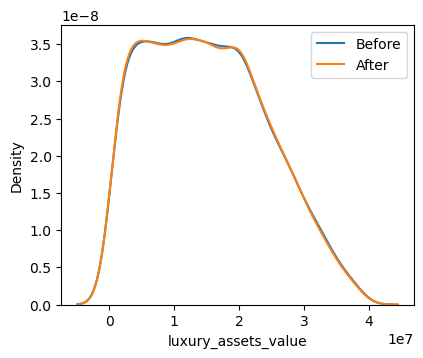

In [120]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='luxury_assets_value',label='Before')
sns.kdeplot(df_ran1,x='luxury_assets_value',label='After')
plt.legend()
plt.show()

<b>Random value imputation on bank_asset_value</b>

In [121]:
df_ran1.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value       0
luxury_assets_value           0
bank_asset_value            426
loan_status                   0
dtype: int64

In [122]:
bav_missing=df_ran1['bank_asset_value'].isnull().sum()
bav_missing

426

In [123]:
#creating pool
bav_pool=df['bank_asset_value'].dropna().sample(bav_missing).values

In [124]:
#imputing values
df_ran1['bank_asset_value'][df_ran1['bank_asset_value'].isnull()]=bav_pool

C:\Users\manish singh\AppData\Local\Temp\ipykernel_3604\1489337337.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ran1['bank_asset_value'][df_ran1['bank_asset_value'].isnull()]=bav_pool


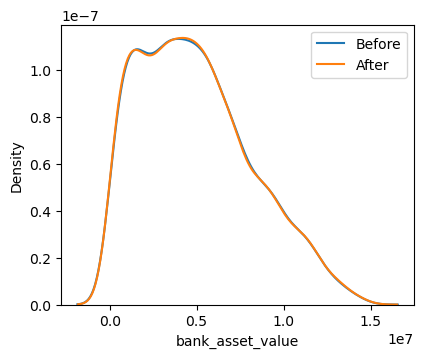

In [125]:
#comparing distribution before and after imputation

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.kdeplot(df,x='bank_asset_value',label='Before')
sns.kdeplot(df_ran1,x='bank_asset_value',label='After')
plt.legend()
plt.show()

In [126]:
df_ran1.isnull().sum()

no_of_dependents              0
education                   640
self_employed               341
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value      0
commercial_assets_value       0
luxury_assets_value           0
bank_asset_value              0
loan_status                   0
dtype: int64

> Random value imputation is preferable for all four columns as there is no difference in curves after imputation

# Conclusion:
> <b>Random Value Imputation gives best reults on all four columns as compare to Mean and Median imputation as there is no 
> difference in curves after imputation.</b>

# <center>====Outliers====<center>

In [127]:
numerical

['no_of_dependents',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value']

# Identifing outliers

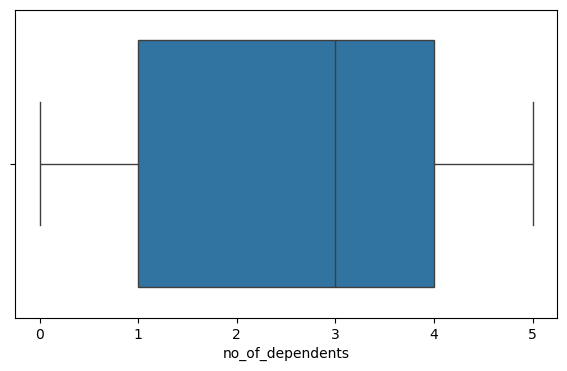

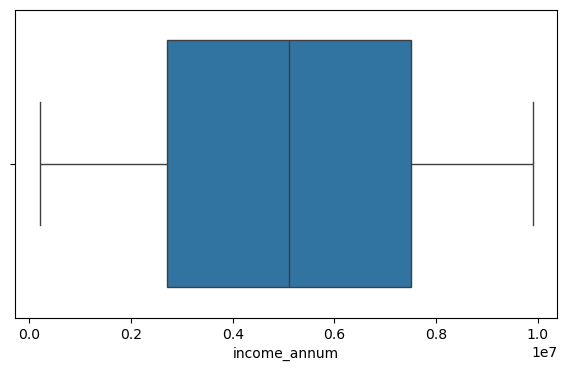

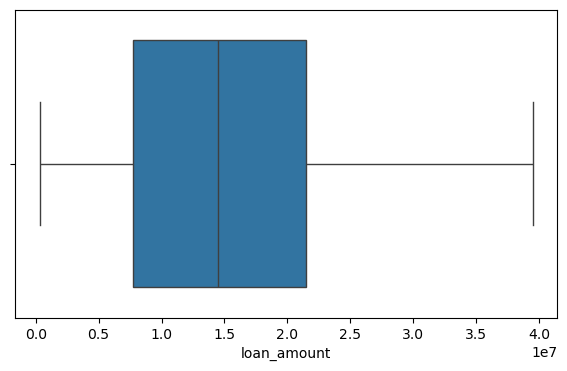

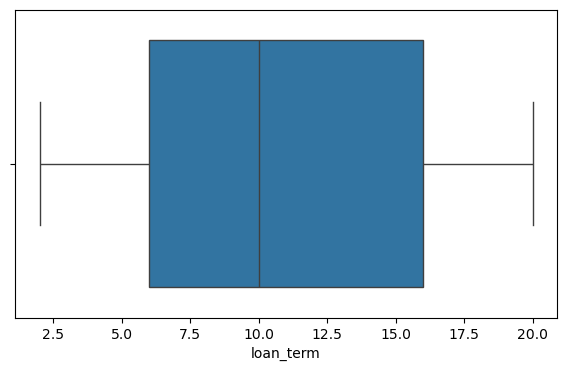

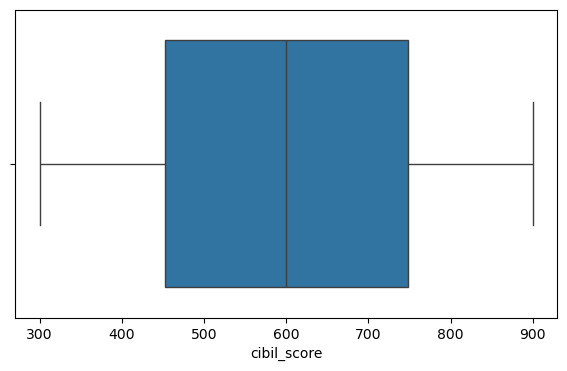

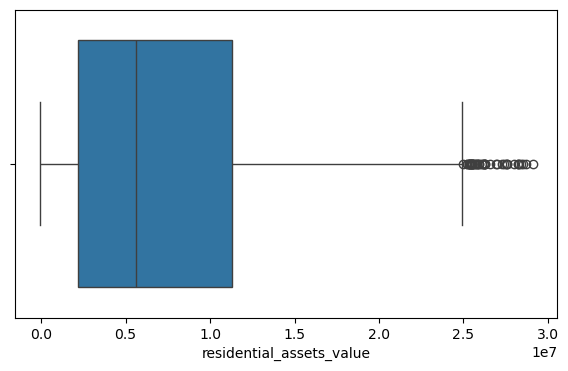

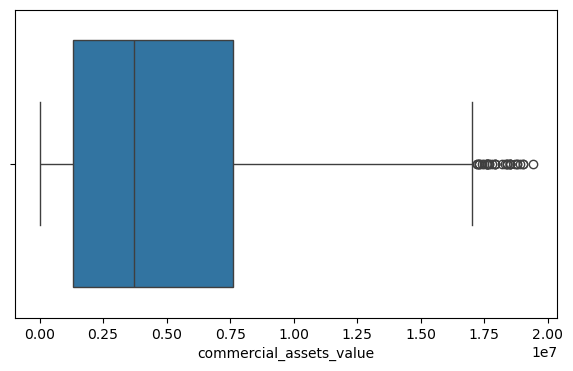

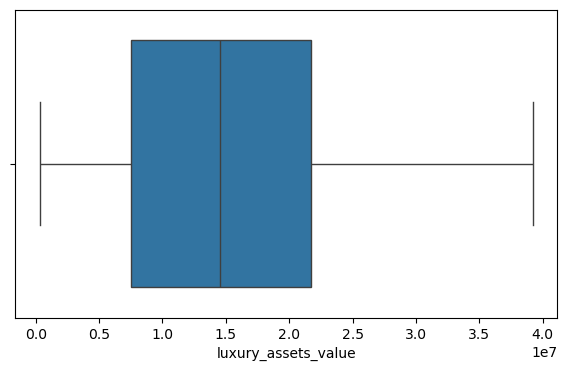

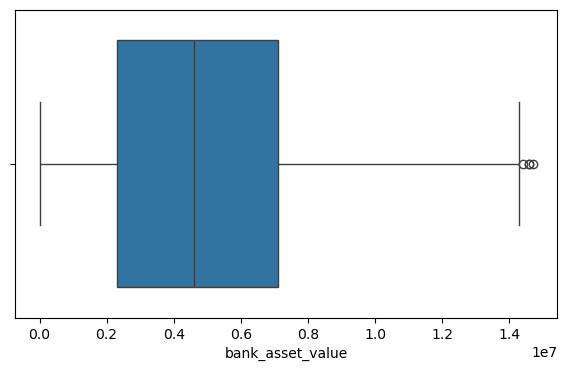

In [128]:
for num in df[numerical]:
    plt.figure(figsize=(7,4))
    sns.boxplot(df,x=num)

In [129]:
cols=['residential_assets_value','commercial_assets_value','bank_asset_value']

In [130]:
df_ran1[numerical].isnull().sum()

no_of_dependents            0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
dtype: int64

# <center>Handling outliers by boundary value method<center>

In [131]:
# Calculating boundary values

for col in df_ran1[cols]:
    print(f'Upper Boundary Value {col} : {df_ran1[col].mean()+3*df_ran1[col].std()}')
    print(f'Lower Boundary Value {col} : {df_ran1[col].mean()-3*df_ran1[col].std()}')
    print("="*80)

Upper Boundary Value residential_assets_value : 27143776.14096736
Lower Boundary Value residential_assets_value : -12120445.150102988
Upper Boundary Value commercial_assets_value : 18148542.748948768
Lower Boundary Value commercial_assets_value : -8169624.969609343
Upper Boundary Value bank_asset_value : 14664222.566193946
Lower Boundary Value bank_asset_value : -4751128.164694765


<b>On residential_assets_value column</b>

In [132]:
# finding boundary values

rav_ub=df_ran1['residential_assets_value'].mean()+3*df_ran1['residential_assets_value'].std()
rav_lb=df_ran1['residential_assets_value'].mean()-3*df_ran1['residential_assets_value'].std()

In [133]:
print('rav_ub:',rav_ub)
print()
print('rav_lb:',rav_lb)

rav_ub: 27143776.14096736

rav_lb: -12120445.150102988


In [134]:
#checking no. of outliers

df_ran1[(df_ran1['residential_assets_value']>rav_ub) | (df_ran1['residential_assets_value']<rav_lb)].shape

(14, 12)

In [135]:
#Trimming 

trimmed_rav=df_ran1[(df_ran1['residential_assets_value']<rav_ub) & (df_ran1['residential_assets_value']>rav_lb)].head()
trimmed_rav

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,NaN,No,9600000,29900000,12,778,2400000.0,17600000.0,13300000.0,8000000.0,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,5200000.0,2200000.0,8800000.0,3300000.0,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000.0,14500000.0,33300000.0,12800000.0,Rejected
3,3,NaN,No,8200000,30700000,8,467,18200000.0,3300000.0,23300000.0,7900000.0,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000.0,8200000.0,29400000.0,5000000.0,Rejected


In [136]:
# capping 
df_ran1['residential_assets_value']=np.where(df_ran1['residential_assets_value']>rav_ub,rav_ub,
                np.where(df['residential_assets_value']<rav_lb,rav_lb,
                df['residential_assets_value']))

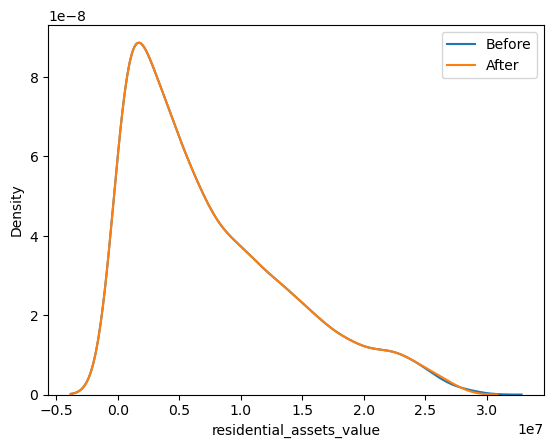

In [137]:
#compareing distribution before and after handling outliers

sns.kdeplot(df,x='residential_assets_value',label='Before')
sns.kdeplot(df_ran1,x='residential_assets_value',label='After',)
plt.legend()

<b>on commercial_assets_value</b>

In [138]:
cav_ub=df_ran1['commercial_assets_value'].mean()+3*df_ran1['commercial_assets_value'].std()
cav_lb=df_ran1['commercial_assets_value'].mean()-3*df_ran1['commercial_assets_value'].std()

In [139]:
print("cav_ub:",cav_ub)
print("cav_lb:",cav_lb)

cav_ub: 18148542.748948768
cav_lb: -8169624.969609343


In [140]:
#checking no. of outliers 
df_ran1[(df_ran1['commercial_assets_value']>cav_ub) | (df_ran1['commercial_assets_value']<cav_lb)].shape

(16, 12)

In [141]:
#trimming 
trimmed_cav=df_ran1[(df_ran1['commercial_assets_value']<cav_ub) & (df_ran1['commercial_assets_value']>cav_lb)].shape
print(trimmed_cav)

(4253, 12)


In [142]:
#capping 
df_ran1['commercial_assets_value']=np.where(df['commercial_assets_value']>cav_ub,cav_ub,
                                           np.where(df['commercial_assets_value']<cav_lb,cav_lb,
                                           df['commercial_assets_value']))

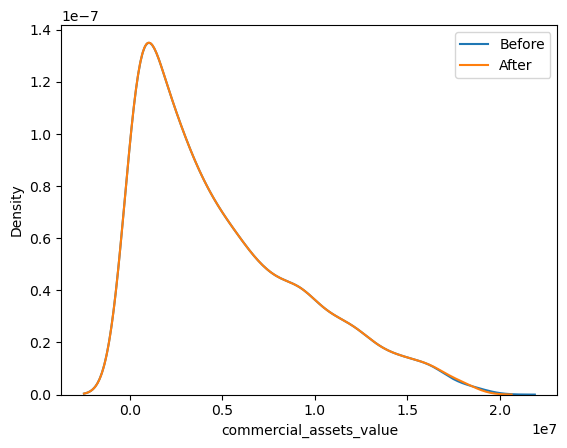

In [143]:
#compareing distribution before and after handling outliers

sns.kdeplot(df,x='commercial_assets_value',label='Before')
sns.kdeplot(df_ran1,x='commercial_assets_value',label='After',)
plt.legend()

<b>on bank_asset_value</b>

In [144]:
bav_ub=df_ran1['bank_asset_value'].mean()+3*df_ran1['bank_asset_value'].std()
bav_lb=df_ran1['bank_asset_value'].mean()-3*df_ran1['bank_asset_value'].std()

In [145]:
print("bav_ub:",bav_ub)
print("bav_lb:",bav_lb)

bav_ub: 14664222.566193946
bav_lb: -4751128.164694765


In [146]:
#checking no. of outliers
df_ran1[(df_ran1["bank_asset_value"]>bav_ub) | (df_ran1['bank_asset_value']<bav_lb)].shape

(1, 12)

In [147]:
#trimming
trimmed_bav=df_ran1[(df_ran1["bank_asset_value"]<bav_ub) & (df_ran1['bank_asset_value']>bav_lb)].shape
trimmed_bav

(4268, 12)

In [148]:
#capping
df_ran1['bank_asset_value']=np.where(df_ran1['bank_asset_value']>bav_ub,bav_ub,
                                    np.where(df_ran1['bank_asset_value']<bav_lb,bav_lb,
                                    df_ran1['bank_asset_value']))

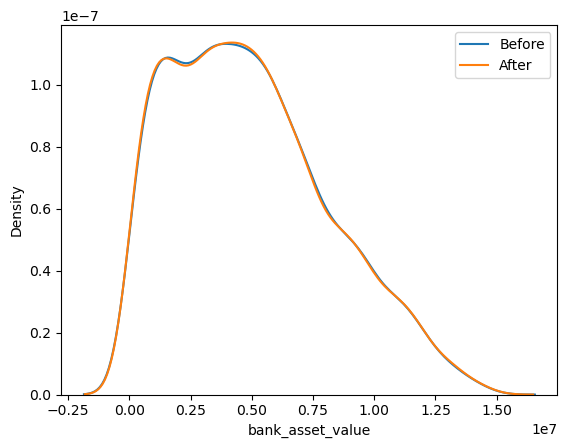

In [149]:
#compareing distribution before and after handling outliers

sns.kdeplot(df,x='bank_asset_value',label='Before')
sns.kdeplot(df_ran1,x='bank_asset_value',label='After',)
plt.legend()

# <center>Handling outliers by IQR method</center>

<b>On residential_assets_value column</b>

In [150]:
#Finding IQR 
rav_pcile25=df_ran1['residential_assets_value'].quantile(0.25)
rav_pcile75=df_ran1['residential_assets_value'].quantile(0.75)

In [151]:
print(rav_pcile25)
print()
print(rav_pcile75)

2200000.0

11300000.0


In [152]:
rav_IQR=rav_pcile75-rav_pcile25
print(rav_IQR)

9100000.0


In [153]:
#calculating upper and lower limit 
rav_ul=rav_pcile75 + 1.5*rav_IQR
rav_ll=rav_pcile25 - 1.5*rav_IQR

In [154]:
print(rav_ul)
print(rav_ll)

24950000.0
-11450000.0


In [155]:
# checking no. of outliers
df_ran1[(df_ran1['residential_assets_value']>rav_ul) | (df_ran1['residential_assets_value']<rav_ll)].shape

(48, 12)

In [156]:
# Trimmig
trimmed_rav=df_ran1[(df_ran1['residential_assets_value']<=rav_ul) & (df['residential_assets_value']>=rav_ll)].shape
print(trimmed_rav)

(3838, 12)


In [157]:
#capping 
df_ran1['residential_assets_value']=np.where(df['residential_assets_value']>rav_ul,rav_ul,
                                           np.where(df['residential_assets_value']<rav_ll,rav_ll,
                                                   df_ran['residential_assets_value']))

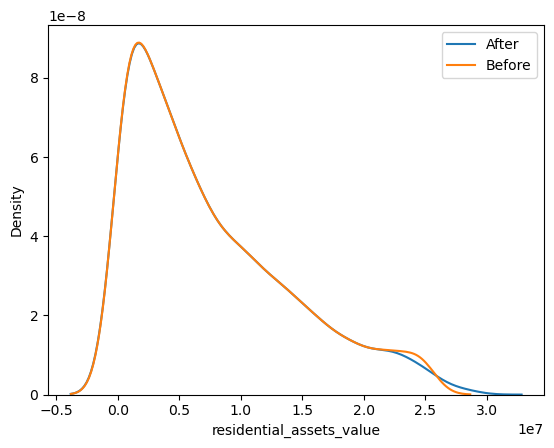

In [158]:
#compareing distribution before and after handling outliers

sns.kdeplot(df,x='residential_assets_value',label='After')
sns.kdeplot(df_ran1,x='residential_assets_value',label='Before')
plt.legend()

<Axes: xlabel='residential_assets_value'>

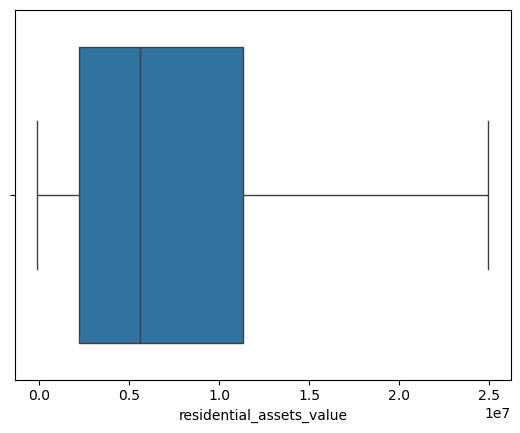

In [159]:
sns.boxplot(df_ran1,x='residential_assets_value')

 <b>on commercial_assets_value</b>

In [160]:
#Finding IQR 
pcile25=df_ran1['commercial_assets_value'].quantile(0.25)
pcile75=df_ran1['commercial_assets_value'].quantile(0.75)

In [161]:
print(pcile25)
print()
print(pcile75)

1300000.0

7600000.0


In [162]:
IQR=pcile75-pcile25
print(IQR)

6300000.0


In [163]:
#calculating upper and lower limit 
ul=pcile75 + 1.5*IQR
ll=pcile25 - 1.5*IQR

In [164]:
print("ul:",ul)
print()
print("ll:",ll)

ul: 17050000.0

ll: -8150000.0


In [165]:
# checking no. of outliers
df_ran1[(df_ran1['commercial_assets_value']>ul) | (df_ran1['commercial_assets_value']<ll)].shape

(34, 12)

In [166]:
# Trimmig
trimmed_cav=df_ran1[(df_ran1['commercial_assets_value']<=ul) & (df['commercial_assets_value']>=ll)].shape
print(trimmed_cav)

(4107, 12)


In [167]:
#capping 
df_ran1['commercial_assets_value']=np.where(df['commercial_assets_value']>ul,ul,
                                           np.where(df['commercial_assets_value']<ll,ll,
                                                   df_ran['commercial_assets_value']))

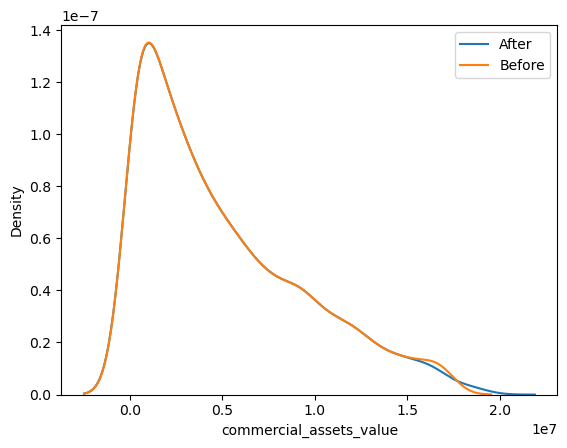

In [168]:
#compareing distribution before and after handling outliers

sns.kdeplot(df,x='commercial_assets_value',label='After')
sns.kdeplot(df_ran1,x='commercial_assets_value',label='Before')
plt.legend()

<Axes: xlabel='commercial_assets_value'>

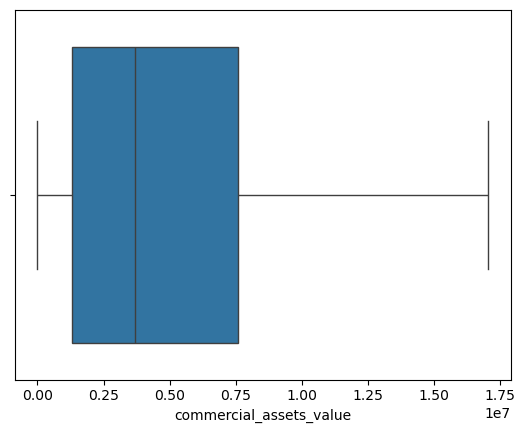

In [169]:
sns.boxplot(df_ran1,x='commercial_assets_value')

# <center>Handling outliers by Percentile Method</center>

<b>on bank_asset_value</b>

In [170]:
#upper limit =95
#lower limit =5

In [171]:
#Calculating percentile 
ul_bav=df_ran1['bank_asset_value'].quantile(0.95)
ll_bav=df_ran1['bank_asset_value'].quantile(0.05)

In [172]:
print("ul_bav:",ul_bav)
print("ll_bav:",ll_bav)

ul_bav: 11100000.0
ll_bav: 500000.0


In [173]:
# checking no. of outliers

df_ran1[(df_ran1['bank_asset_value']>ul_bav) | (df_ran1['bank_asset_value']<ll_bav)].shape

(406, 12)

In [174]:
trimmed_bav=df_ran1[(df_ran1['bank_asset_value']<ul_bav) & (df_ran1['bank_asset_value']>ll_bav)].shape
trimmed_bav

(3808, 12)

In [175]:
#capping
df_ran1["bank_asset_value"]=np.where(df_ran1['bank_asset_value']>ul_bav,ul_bav,
                                    np.where(df_ran1['bank_asset_value']<ll_bav,ll_bav,
                                             df_ran1['bank_asset_value']))

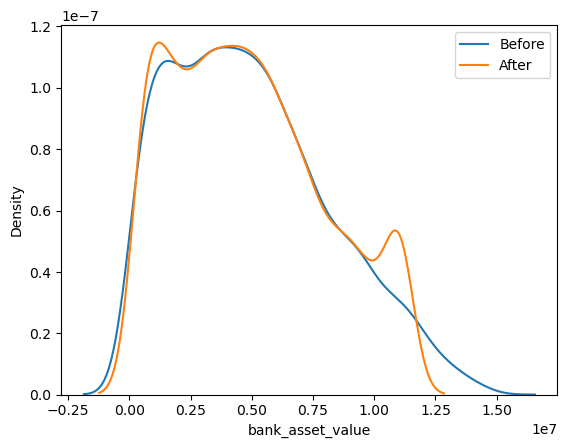

In [176]:
#compareing distribution before and after handling outliers

sns.kdeplot(df,x='bank_asset_value',label='Before')
sns.kdeplot(df_ran1,x='bank_asset_value',label='After')
plt.legend()

# <center>Handling outliers by z-score</center>

<b>on residential_assets_value</b>

In [177]:
df_ran1['Z_score_rav']=abs((df_ran1['residential_assets_value']-df_ran1['residential_assets_value'].mean())
                                        /df['residential_assets_value'].std())

In [178]:
df_ran1[['residential_assets_value','Z_score_rav']].head()

,residential_assets_value,Z_score_rav
0,2400000.0,0.775926
1,NaN,NaN
2,7100000.0,0.054303
3,18200000.0,1.649955
4,12400000.0,0.759442


In [179]:
df_ran1['Z_score_rav'].describe()

count    3885.000000
mean        0.812300
std         0.569723
min         0.007112
25%         0.392084
50%         0.759442
75%         1.052292
max         2.686328
Name: Z_score_rav, dtype: float64

In [180]:
df_ran1[(df_ran1['Z_score_rav']>2.5)].head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,Z_score_rav
60,2,Not Graduate,No,8500000,18900000,18,478,23800000.0,16300000.0,25900000.0,11100000.0,Rejected,2.509761
62,5,Not Graduate,Yes,8800000,28900000,6,365,24400000.0,8600000.0,27400000.0,4700000.0,Rejected,2.601883
82,2,Not Graduate,Yes,9900000,21200000,16,363,24950000.0,11400000.0,26600000.0,6800000.0,Rejected,2.686328
89,2,Not Graduate,No,9800000,37600000,10,641,24100000.0,0.0,23400000.0,7600000.0,Approved,2.555822
98,4,NaN,No,9400000,29400000,12,562,24950000.0,15200000.0,36400000.0,7100000.0,Approved,2.686328


In [181]:
df_ran1[(df_ran1['Z_score_rav']>2.5)].shape

(89, 13)

In [182]:
#trimming 
trimmed_rav=df_ran1[(df_ran1['Z_score_rav']<2.5)]
print(trimmed_bav)

(3808, 12)


In [183]:
trimmed_rav[trimmed_rav['Z_score_rav']==trimmed_rav['Z_score_rav']
            .max()]['residential_assets_value']

1972    23700000.0
2341    23700000.0
2373    23700000.0
3937    23700000.0
Name: residential_assets_value, dtype: float64

In [184]:
#capping
capped_df = df_ran1.copy()

In [185]:
capped_df['residential_assets_value']  = np.where(capped_df['Z_score_rav']>2.5,
                                           2350,capped_df['residential_assets_value'])

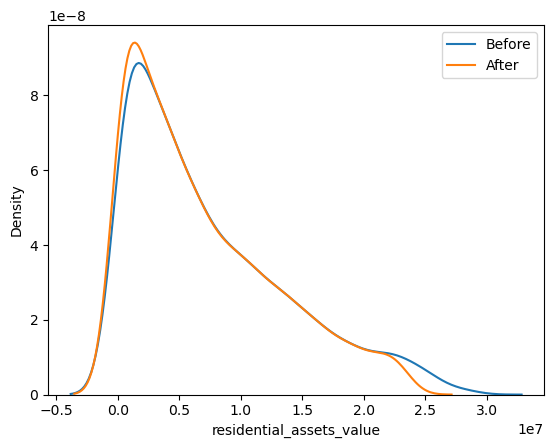

In [186]:
#compareing distribution before and after handling outliers

sns.kdeplot(df,x='residential_assets_value',label='Before')
sns.kdeplot(capped_df,x='residential_assets_value',label='After')
plt.legend()